Imports OK | Device: cpu
MNIST charge | Train: 60000 Test: 10000


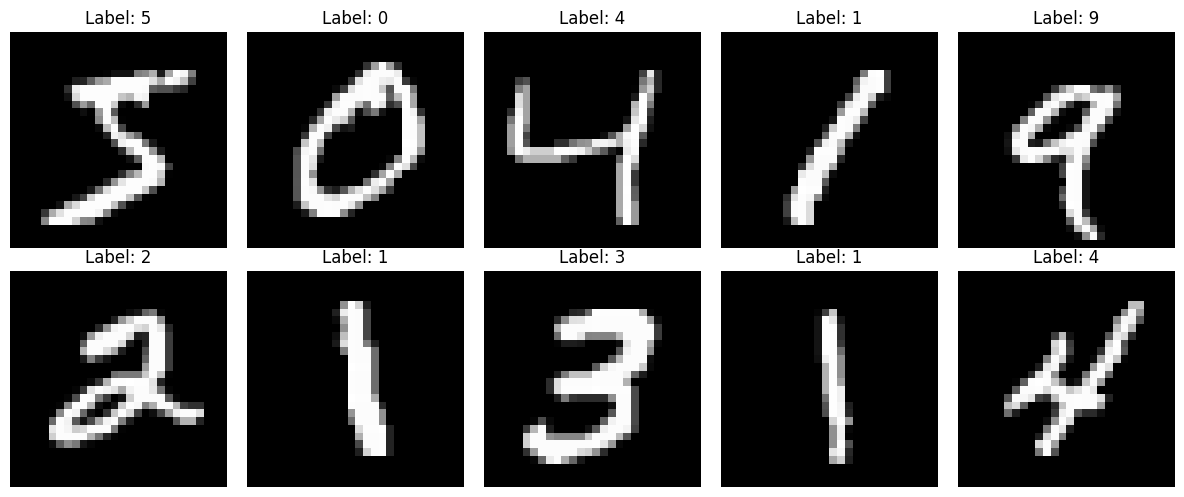

Correlation croisee:
 tensor([[ 6.,  8.],
        [12., 14.]])
Max Pooling manuel:
 tensor([[6., 8.],
        [9., 7.]])
Max Pooling PyTorch:
 tensor([[6., 8.],
        [9., 7.]])
LeNet cree | Parametres: 61978

--- Entrainement CNN LeNet ---
Epoch [1/5] TrainLoss:0.2764 TestLoss:0.0763 TestAcc:0.9745
Epoch [2/5] TrainLoss:0.0765 TestLoss:0.0585 TestAcc:0.9816
Epoch [3/5] TrainLoss:0.0587 TestLoss:0.0383 TestAcc:0.9877
Epoch [4/5] TrainLoss:0.0467 TestLoss:0.0431 TestAcc:0.9872
Epoch [5/5] TrainLoss:0.0390 TestLoss:0.0408 TestAcc:0.9865

--- Entrainement MLP (comparaison) ---
Epoch [1/5] TrainLoss:0.3085 TestLoss:0.1277 TestAcc:0.9607
Epoch [2/5] TrainLoss:0.1531 TestLoss:0.1111 TestAcc:0.9667
Epoch [3/5] TrainLoss:0.1221 TestLoss:0.0867 TestAcc:0.9744
Epoch [4/5] TrainLoss:0.1033 TestLoss:0.0750 TestAcc:0.9765
Epoch [5/5] TrainLoss:0.0939 TestLoss:0.0833 TestAcc:0.9735

MLP params:235146 TestAcc:0.9735
CNN params:61978 TestAcc:0.9865


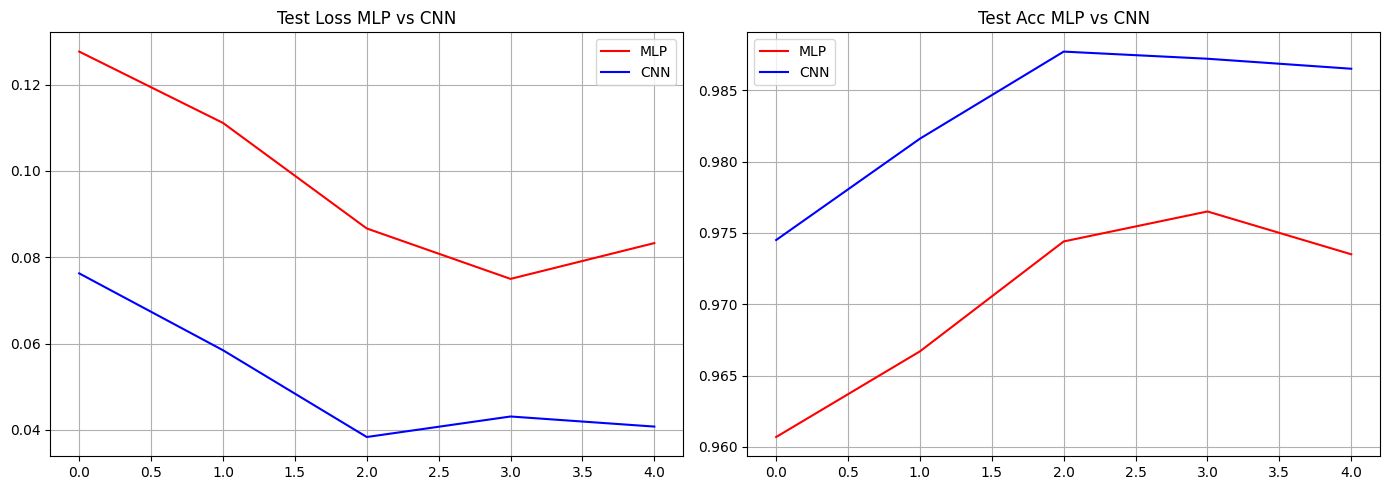


--- Modele Sans Padding ---
Epoch [1/3] TrainLoss:0.2420 TestLoss:0.0754 TestAcc:0.9746
Epoch [2/3] TrainLoss:0.0697 TestLoss:0.0543 TestAcc:0.9822
Epoch [3/3] TrainLoss:0.0497 TestLoss:0.0472 TestAcc:0.9846

--- Modele Avec Padding ---
Epoch [1/3] TrainLoss:0.2311 TestLoss:0.0664 TestAcc:0.9794
Epoch [2/3] TrainLoss:0.0666 TestLoss:0.0579 TestAcc:0.9816
Epoch [3/3] TrainLoss:0.0483 TestLoss:0.0469 TestAcc:0.9845

--- Modele Plus de Filtres ---
Epoch [1/3] TrainLoss:0.1220 TestLoss:0.0416 TestAcc:0.9865
Epoch [2/3] TrainLoss:0.0396 TestLoss:0.0307 TestAcc:0.9898
Epoch [3/3] TrainLoss:0.0268 TestLoss:0.0326 TestAcc:0.9895

=== TABLEAU COMPARATIF ===
Sans Padding: 0.9846 (98.46%)
Avec Padding: 0.9845 (98.45%)
Plus de Filtres: 0.9895 (98.95%)


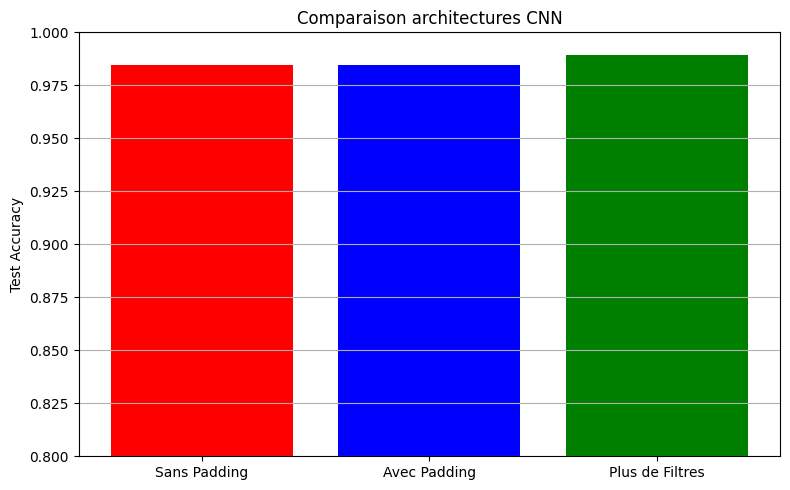

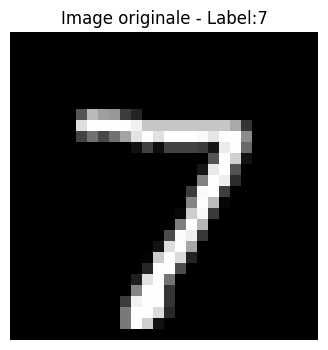

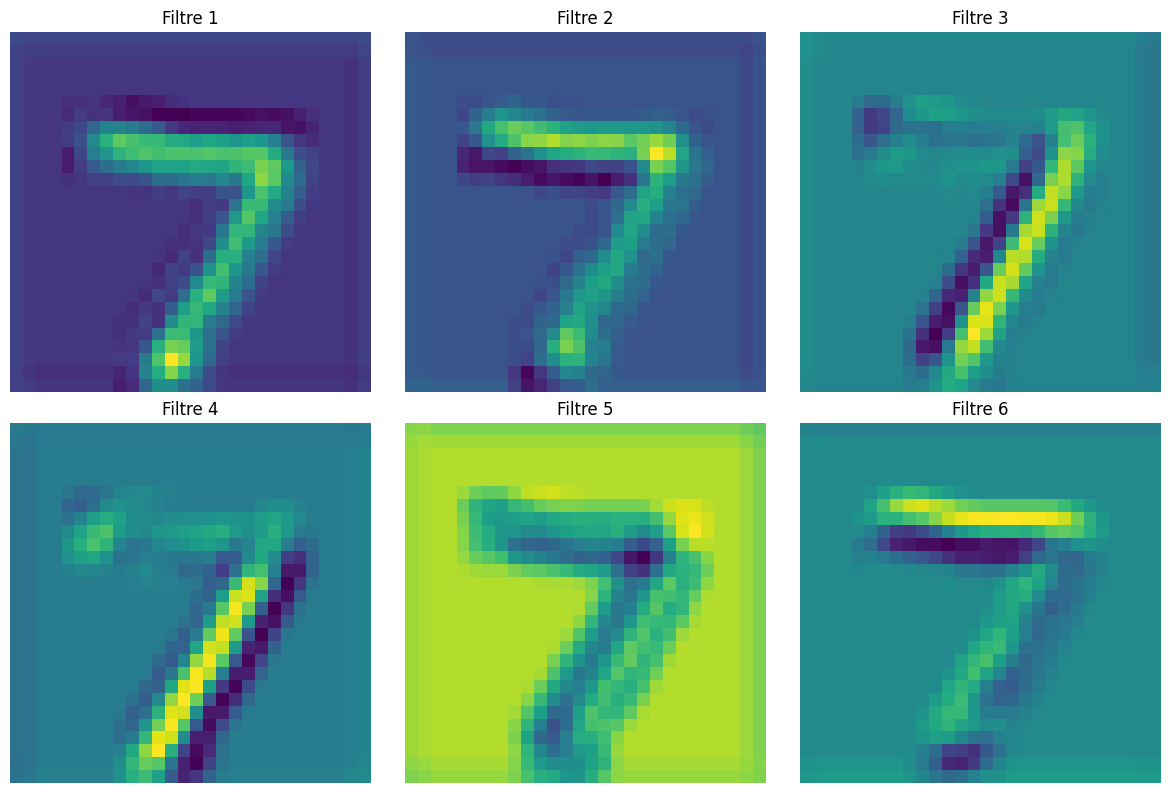

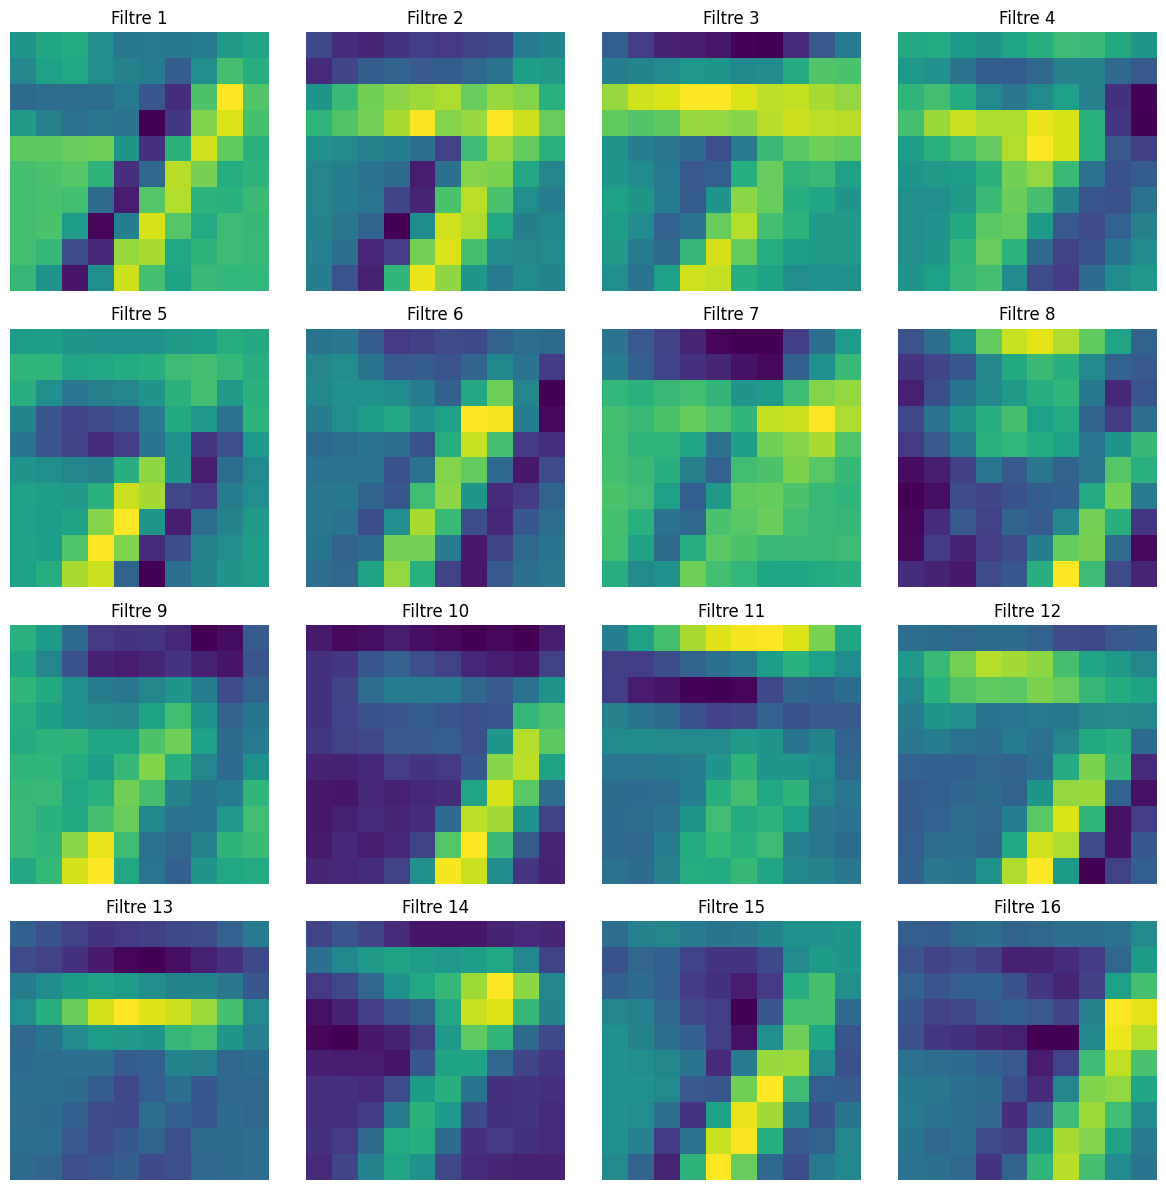


=== METRIQUES FINALES CNN ===
Test Accuracy: 0.9865 (98.65%)
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      1.00      0.99      1032
           3       0.98      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.96      0.97      1028
           8       0.98      0.99      0.98       974
           9       0.97      0.99      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



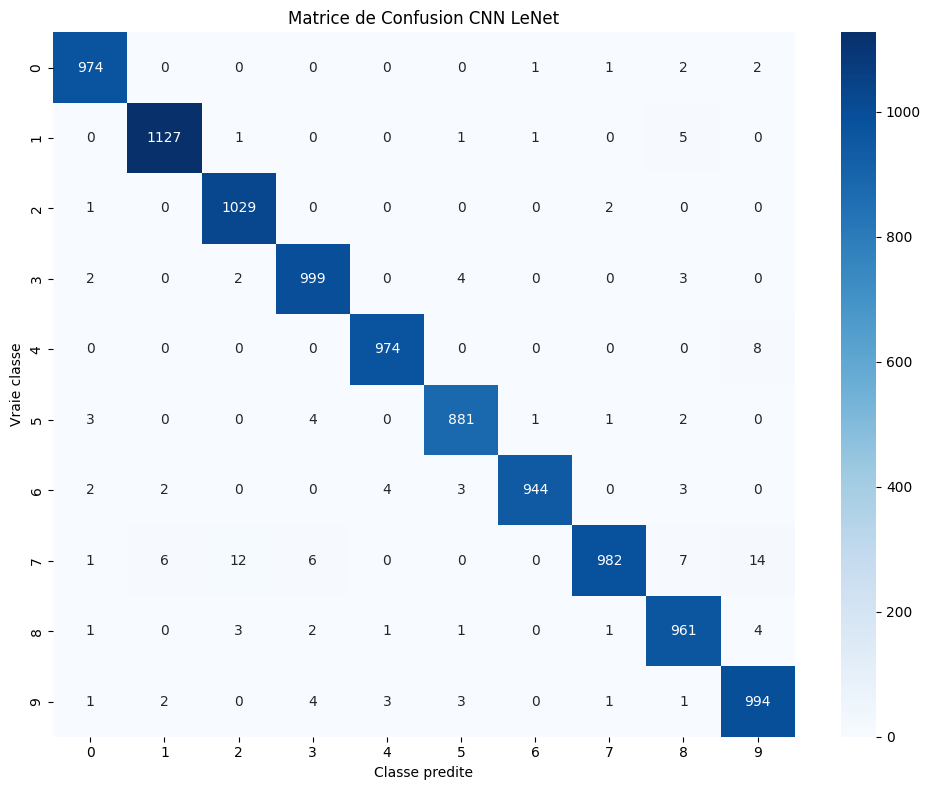


   QUESTION DE SYNTHESE - PARTIE II

1. POURQUOI LE CNN EST MEILLEUR QUE LE MLP POUR LES IMAGES
- Le MLP aplatit l'image et perd la structure spatiale 2D.
- Le CNN exploite la localite : chaque filtre detecte un motif local.
- Partage des poids : un filtre est applique partout -> moins de parametres.
- Hierarchie : Conv1 detecte les bords, Conv2 detecte les formes complexes.

2. INFLUENCE DES HYPERPARAMETRES
- Padding : preserve la taille spatiale, ameliore l'accuracy.
- Stride : reduit la taille de sortie, accelere le calcul.
- Pooling : reduit la dimensionnalite, apporte l'invariance aux translations.
- Nombre de filtres : plus de filtres = meilleure accuracy mais plus de calcul.

3. CONCLUSION
- Le CNN est superieur au MLP pour les images car il exploite la structure spatiale 2D.
- Avec moins de parametres, le CNN atteint une meilleure accuracy.

PROJET PARTIE II TERMINE !


In [1]:
# ============================================================
# PARTIE II — CNN COMPLET EN UNE SEULE CELLULE
# ============================================================
import torch, torch.nn as nn, torch.optim as optim, torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision, torchvision.transforms as transforms
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

torch.manual_seed(42); np.random.seed(42)
device = torch.device("cpu")
print("Imports OK | Device:", device)

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader   = DataLoader(test_dataset, batch_size=64, shuffle=False)
print("MNIST charge | Train:", len(train_dataset), "Test:", len(test_dataset))

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray'); ax.set_title(f'Label: {label}'); ax.axis('off')
plt.tight_layout(); plt.savefig('mnist_exemples.png', dpi=150); plt.show()

def correlation_croisee_2d(X, K):
    h_x, w_x = X.shape; h_k, w_k = K.shape
    h_out, w_out = h_x - h_k + 1, w_x - w_k + 1
    Y = torch.zeros(h_out, w_out)
    for i in range(h_out):
        for j in range(w_out):
            Y[i, j] = (X[i:i+h_k, j:j+w_k] * K).sum()
    return Y

X_test_conv = torch.tensor([[1.,2.,3.],[4.,5.,6.],[7.,8.,9.]])
K_test = torch.tensor([[1.,0.],[0.,1.]])
print("Correlation croisee:\n", correlation_croisee_2d(X_test_conv, K_test))

def max_pooling_2d(X, pool_size=2, stride=2):
    h, w = X.shape
    h_out, w_out = (h - pool_size)//stride + 1, (w - pool_size)//stride + 1
    Y = torch.zeros(h_out, w_out)
    for i in range(h_out):
        for j in range(w_out):
            Y[i,j] = X[i*stride:i*stride+pool_size, j*stride:j*stride+pool_size].max()
    return Y

X_pool = torch.tensor([[1.,3.,2.,4.],[5.,6.,7.,8.],[9.,2.,3.,1.],[4.,5.,6.,7.]])
print("Max Pooling manuel:\n", max_pooling_2d(X_pool))
X_4d = X_pool.unsqueeze(0).unsqueeze(0)
print("Max Pooling PyTorch:\n", F.max_pool2d(X_4d, 2, 2).squeeze())

class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5, padding=2)
        self.pool1 = nn.AvgPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.pool2 = nn.AvgPool2d(2, 2)
        self.conv1x1 = nn.Conv2d(16, 16, 1)
        self.fc1 = nn.Linear(16*5*5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
    def forward(self, x):
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = torch.relu(self.conv1x1(x))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

model_cnn = LeNet().to(device)
total = sum(p.numel() for p in model_cnn.parameters())
print("LeNet cree | Parametres:", total)

def train_cnn(model, train_loader, test_loader, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    history = {'train_loss':[], 'test_loss':[], 'train_acc':[], 'test_acc':[]}
    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(Xb)
            loss = criterion(out, yb)
            loss.backward(); optimizer.step()
            train_loss += loss.item()
            correct += (out.argmax(1) == yb).sum().item(); total += yb.size(0)
        train_loss /= len(train_loader); train_acc = correct/total
        model.eval()
        test_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                out = model(Xb)
                loss = criterion(out, yb)
                test_loss += loss.item()
                correct += (out.argmax(1) == yb).sum().item(); total += yb.size(0)
        test_loss /= len(test_loader); test_acc = correct/total
        history['train_loss'].append(train_loss); history['test_loss'].append(test_loss)
        history['train_acc'].append(train_acc); history['test_acc'].append(test_acc)
        print(f"Epoch [{epoch+1}/{epochs}] TrainLoss:{train_loss:.4f} TestLoss:{test_loss:.4f} TestAcc:{test_acc:.4f}")
    return history

print("\n--- Entrainement CNN LeNet ---")
history_cnn = train_cnn(model_cnn, train_loader, test_loader, epochs=5)

class MLP_Image(nn.Module):
    def __init__(self):
        super(MLP_Image, self).__init__()
        self.fc1 = nn.Linear(28*28, 256); self.fc2 = nn.Linear(256, 128); self.fc3 = nn.Linear(128, 10)
        self.relu = nn.ReLU(); self.drop = nn.Dropout(0.3)
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.drop(self.relu(self.fc1(x)))
        x = self.drop(self.relu(self.fc2(x)))
        return self.fc3(x)

model_mlp_img = MLP_Image().to(device)
total_mlp = sum(p.numel() for p in model_mlp_img.parameters())
print("\n--- Entrainement MLP (comparaison) ---")
history_mlp_img = train_cnn(model_mlp_img, train_loader, test_loader, epochs=5)
print(f"\nMLP params:{total_mlp} TestAcc:{history_mlp_img['test_acc'][-1]:.4f}")
print(f"CNN params:{total} TestAcc:{history_cnn['test_acc'][-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_mlp_img['test_loss'], label='MLP', color='red')
axes[0].plot(history_cnn['test_loss'], label='CNN', color='blue')
axes[0].set_title('Test Loss MLP vs CNN'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(history_mlp_img['test_acc'], label='MLP', color='red')
axes[1].plot(history_cnn['test_acc'], label='CNN', color='blue')
axes[1].set_title('Test Acc MLP vs CNN'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.savefig('mlp_vs_cnn.png', dpi=150); plt.show()

results = {}

class CNN_NoPadding(nn.Module):
    def __init__(self):
        super(CNN_NoPadding, self).__init__()
        self.conv1 = nn.Conv2d(1,6,3,padding=0); self.conv2 = nn.Conv2d(6,16,3,padding=0)
        self.pool = nn.MaxPool2d(2,2); self.fc1 = nn.Linear(16*5*5,120); self.fc2 = nn.Linear(120,10)
    def forward(self,x):
        x = self.pool(torch.relu(self.conv1(x))); x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0),-1); x = torch.relu(self.fc1(x)); return self.fc2(x)

class CNN_Padding(nn.Module):
    def __init__(self):
        super(CNN_Padding, self).__init__()
        self.conv1 = nn.Conv2d(1,6,3,padding=1); self.conv2 = nn.Conv2d(6,16,3,padding=1)
        self.pool = nn.MaxPool2d(2,2); self.fc1 = nn.Linear(16*7*7,120); self.fc2 = nn.Linear(120,10)
    def forward(self,x):
        x = self.pool(torch.relu(self.conv1(x))); x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0),-1); x = torch.relu(self.fc1(x)); return self.fc2(x)

class CNN_MoreFilters(nn.Module):
    def __init__(self):
        super(CNN_MoreFilters, self).__init__()
        self.conv1 = nn.Conv2d(1,32,3,padding=1); self.conv2 = nn.Conv2d(32,64,3,padding=1)
        self.pool = nn.MaxPool2d(2,2); self.fc1 = nn.Linear(64*7*7,256); self.fc2 = nn.Linear(256,10)
    def forward(self,x):
        x = self.pool(torch.relu(self.conv1(x))); x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0),-1); x = torch.relu(self.fc1(x)); return self.fc2(x)

print("\n--- Modele Sans Padding ---")
m1 = CNN_NoPadding().to(device); h1 = train_cnn(m1, train_loader, test_loader, epochs=3)
results['Sans Padding'] = h1['test_acc'][-1]

print("\n--- Modele Avec Padding ---")
m2 = CNN_Padding().to(device); h2 = train_cnn(m2, train_loader, test_loader, epochs=3)
results['Avec Padding'] = h2['test_acc'][-1]

print("\n--- Modele Plus de Filtres ---")
m3 = CNN_MoreFilters().to(device); h3 = train_cnn(m3, train_loader, test_loader, epochs=3)
results['Plus de Filtres'] = h3['test_acc'][-1]

print("\n=== TABLEAU COMPARATIF ===")
for nom, acc in results.items():
    print(f"{nom}: {acc:.4f} ({acc*100:.2f}%)")

plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values(), color=['red','blue','green'])
plt.title('Comparaison architectures CNN'); plt.ylabel('Test Accuracy'); plt.ylim(0.8,1.0)
plt.grid(True, axis='y'); plt.tight_layout(); plt.savefig('comparaison_cnn.png', dpi=150); plt.show()

model_cnn.eval()
img, label = test_dataset[0]
img_tensor = img.unsqueeze(0).to(device)
activation_conv1, activation_conv2 = {}, {}
def hook1(m,i,o): activation_conv1['output'] = o.detach()
def hook2(m,i,o): activation_conv2['output'] = o.detach()
h1h = model_cnn.conv1.register_forward_hook(hook1)
h2h = model_cnn.conv2.register_forward_hook(hook2)
with torch.no_grad(): _ = model_cnn(img_tensor)
h1h.remove(); h2h.remove()

plt.figure(figsize=(4,4)); plt.imshow(img.squeeze().cpu(), cmap='gray')
plt.title(f'Image originale - Label:{label}'); plt.axis('off')
plt.savefig('image_originale.png', dpi=150); plt.show()

fmaps1 = activation_conv1['output'].squeeze()
fig, axes = plt.subplots(2,3, figsize=(12,8))
for i, ax in enumerate(axes.flat):
    ax.imshow(fmaps1[i].cpu(), cmap='viridis'); ax.set_title(f'Filtre {i+1}'); ax.axis('off')
plt.tight_layout(); plt.savefig('feature_maps_conv1.png', dpi=150); plt.show()

fmaps2 = activation_conv2['output'].squeeze()
fig, axes = plt.subplots(4,4, figsize=(12,12))
for i, ax in enumerate(axes.flat):
    ax.imshow(fmaps2[i].cpu(), cmap='viridis'); ax.set_title(f'Filtre {i+1}'); ax.axis('off')
plt.tight_layout(); plt.savefig('feature_maps_conv2.png', dpi=150); plt.show()

model_cnn.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        preds = model_cnn(Xb).argmax(1).cpu().numpy()
        all_preds.extend(preds); all_labels.extend(yb.numpy())
all_preds, all_labels = np.array(all_preds), np.array(all_labels)
acc = accuracy_score(all_labels, all_preds)
print(f"\n=== METRIQUES FINALES CNN ===\nTest Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print(classification_report(all_labels, all_preds, target_names=[str(i) for i in range(10)]))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Matrice de Confusion CNN LeNet'); plt.ylabel('Vraie classe'); plt.xlabel('Classe predite')
plt.tight_layout(); plt.savefig('matrice_confusion_cnn.png', dpi=150); plt.show()

print("\n" + "="*60)
print("   QUESTION DE SYNTHESE - PARTIE II")
print("="*60)
print("""
1. POURQUOI LE CNN EST MEILLEUR QUE LE MLP POUR LES IMAGES
- Le MLP aplatit l'image et perd la structure spatiale 2D.
- Le CNN exploite la localite : chaque filtre detecte un motif local.
- Partage des poids : un filtre est applique partout -> moins de parametres.
- Hierarchie : Conv1 detecte les bords, Conv2 detecte les formes complexes.

2. INFLUENCE DES HYPERPARAMETRES
- Padding : preserve la taille spatiale, ameliore l'accuracy.
- Stride : reduit la taille de sortie, accelere le calcul.
- Pooling : reduit la dimensionnalite, apporte l'invariance aux translations.
- Nombre de filtres : plus de filtres = meilleure accuracy mais plus de calcul.

3. CONCLUSION
- Le CNN est superieur au MLP pour les images car il exploite la structure spatiale 2D.
- Avec moins de parametres, le CNN atteint une meilleure accuracy.
""")
print("PROJET PARTIE II TERMINE !")